# I. Importation of librairies and dataset

## 1. Librairies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

## 2. Dataset

In [3]:
df = pd.read_csv('spotify_churn_dataset.csv')

# II. Dataset analysis

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                8000 non-null   int64  
 1   gender                 8000 non-null   object 
 2   age                    8000 non-null   int64  
 3   country                8000 non-null   object 
 4   subscription_type      8000 non-null   object 
 5   listening_time         8000 non-null   int64  
 6   songs_played_per_day   8000 non-null   int64  
 7   skip_rate              8000 non-null   float64
 8   device_type            8000 non-null   object 
 9   ads_listened_per_week  8000 non-null   int64  
 10  offline_listening      8000 non-null   int64  
 11  is_churned             8000 non-null   int64  
dtypes: float64(1), int64(7), object(4)
memory usage: 750.1+ KB
None


## 1. Number of columns/rows

In [5]:
print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Shape: (8000, 12)
Rows: 8000, Columns: 12


## 2. Number of values

In [6]:
# Basic statistics
print(df.describe())

          user_id          age  listening_time  songs_played_per_day  \
count  8000.00000  8000.000000     8000.000000           8000.000000   
mean   4000.50000    37.662125      154.068250             50.127250   
std    2309.54541    12.740359       84.015596             28.449762   
min       1.00000    16.000000       10.000000              1.000000   
25%    2000.75000    26.000000       81.000000             25.000000   
50%    4000.50000    38.000000      154.000000             50.000000   
75%    6000.25000    49.000000      227.000000             75.000000   
max    8000.00000    59.000000      299.000000             99.000000   

         skip_rate  ads_listened_per_week  offline_listening   is_churned  
count  8000.000000            8000.000000        8000.000000  8000.000000  
mean      0.300127               6.943875           0.747750     0.258875  
std       0.173594              13.617953           0.434331     0.438044  
min       0.000000               0.000000      

In [7]:
# Categorical variables summary
categorical_cols = ['gender', 'country', 'subscription_type', 'device_type', 'offline_listening', 'is_churned']
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


gender:
gender
Male      2691
Female    2659
Other     2650
Name: count, dtype: int64

country:
country
AU    1034
US    1032
DE    1015
IN    1011
PK     999
FR     989
UK     966
CA     954
Name: count, dtype: int64

subscription_type:
subscription_type
Premium    2115
Free       2018
Student    1959
Family     1908
Name: count, dtype: int64

device_type:
device_type
Desktop    2778
Web        2623
Mobile     2599
Name: count, dtype: int64

offline_listening:
offline_listening
1    5982
0    2018
Name: count, dtype: int64

is_churned:
is_churned
0    5929
1    2071
Name: count, dtype: int64


## 3. Variables definition

In [8]:
print(df.dtypes)

user_id                    int64
gender                    object
age                        int64
country                   object
subscription_type         object
listening_time             int64
songs_played_per_day       int64
skip_rate                float64
device_type               object
ads_listened_per_week      int64
offline_listening          int64
is_churned                 int64
dtype: object


In [9]:
print(df.head())

   user_id  gender  age country subscription_type  listening_time  \
0        1  Female   54      CA              Free              26   
1        2   Other   33      DE            Family             141   
2        3    Male   38      AU           Premium             199   
3        4  Female   22      CA           Student              36   
4        5   Other   29      US            Family             250   

   songs_played_per_day  skip_rate device_type  ads_listened_per_week  \
0                    23       0.20     Desktop                     31   
1                    62       0.34         Web                      0   
2                    38       0.04      Mobile                      0   
3                     2       0.31      Mobile                      0   
4                    57       0.36      Mobile                      0   

   offline_listening  is_churned  
0                  0           1  
1                  1           0  
2                  1           1  
3     

- **Rows**: Each row represents a unique Spotify user.

- **Columns (Features)**:
  - user_id → Unique identifier for each user
  - gender → User gender (Male/Female/Other)
  - age → User age
  - country → User location
  - subscription_type → Type of Spotify subscription (Free, Premium, Family Student)
  - listening_time → Minutes spent listening per day
  - songs_played_per_day → Number of songs played daily
  - skip_rate → Percentage of songs skipped
  - device_type → Device used (Mobile, Desktop, Web)
  - ads_listened_per_week → Number of ads heard per week
  - offline_listening → Offline mode usage
  - is_churned → Target variable (0 = Active, 1 = Churned)

- **Dataset Type**: Mixed (numeric + categorical)

## 4. Quality

In [10]:
# Data range and potential outliers
numeric_cols = ['age', 'listening_time', 'songs_played_per_day', 'skip_rate', 'ads_listened_per_week']
for col in numeric_cols:
    print(f"\n{col}:")
    print(f"  Min: {df[col].min()}, Max: {df[col].max()}")
    print(f"  Mean: {df[col].mean():.2f}, Median: {df[col].median()}")

    # Check for potential outliers using IQR method
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"  Potential outliers: {len(outliers)}")


age:
  Min: 16, Max: 59
  Mean: 37.66, Median: 38.0
  Potential outliers: 0

listening_time:
  Min: 10, Max: 299
  Mean: 154.07, Median: 154.0
  Potential outliers: 0

songs_played_per_day:
  Min: 1, Max: 99
  Mean: 50.13, Median: 50.0
  Potential outliers: 0

skip_rate:
  Min: 0.0, Max: 0.6
  Mean: 0.30, Median: 0.3
  Potential outliers: 0

ads_listened_per_week:
  Min: 0, Max: 49
  Mean: 6.94, Median: 0.0
  Potential outliers: 1683


## 5. Visualization

In [11]:
plt.style.use('default')
sns.set_palette("husl")

### i. Variables distributions

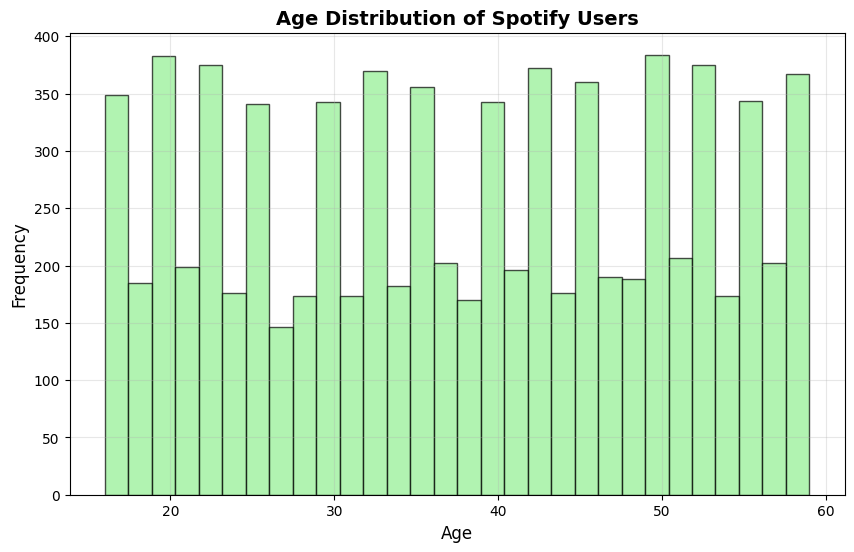

Age statistics:
Min: 16, Max: 59, Mean: 37.7, Median: 38.0


In [12]:
plt.figure(figsize=(10, 6))
plt.hist(df['age'], bins=30, color='lightgreen', alpha=0.7, edgecolor='black')
plt.title('Age Distribution of Spotify Users', fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

print(f"Age statistics:\nMin: {df['age'].min()}, Max: {df['age'].max()}, Mean: {df['age'].mean():.1f}, Median: {df['age'].median()}")

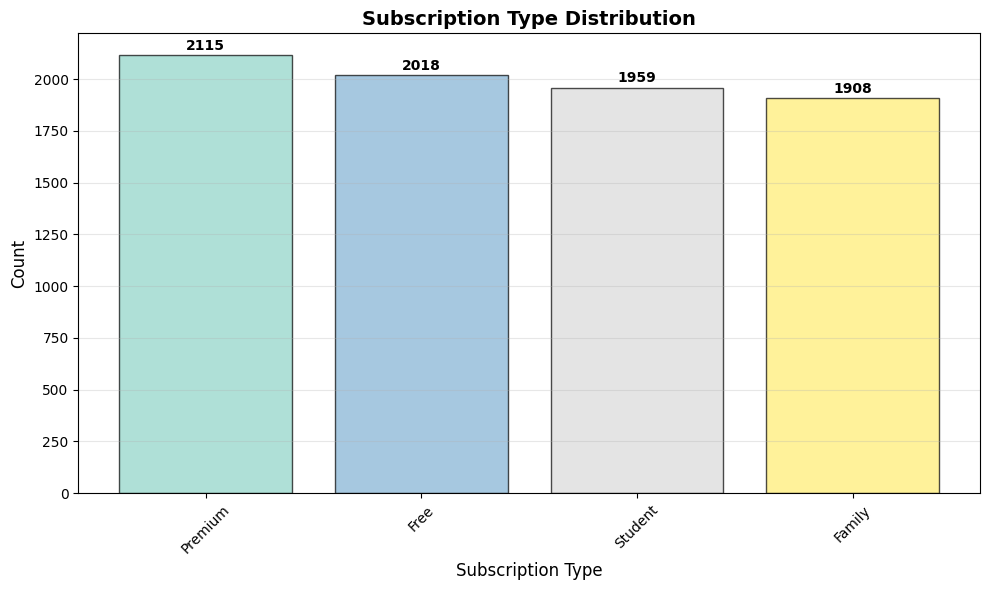

In [13]:
plt.figure(figsize=(10, 6))
subscription_counts = df['subscription_type'].value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(subscription_counts)))
plt.bar(subscription_counts.index, subscription_counts.values, color=colors, alpha=0.7, edgecolor='black')
plt.title('Subscription Type Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Subscription Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
for i, v in enumerate(subscription_counts.values):
    plt.text(i, v + 10, str(v), ha='center', va='bottom', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

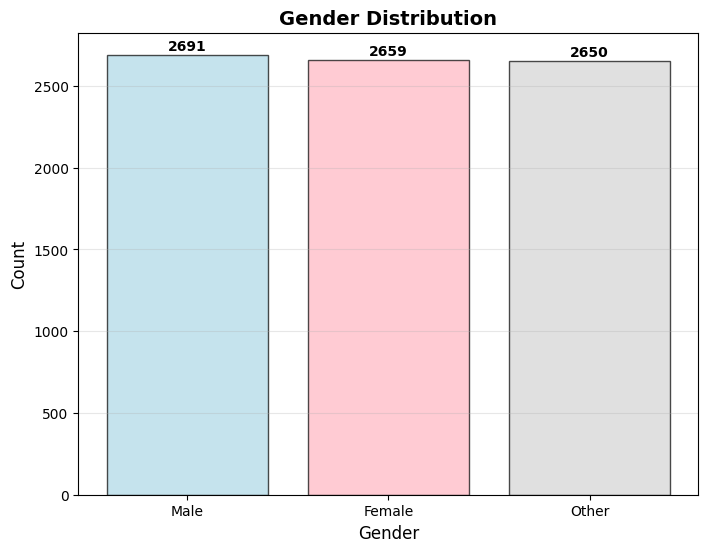

In [14]:
plt.figure(figsize=(8, 6))
gender_counts = df['gender'].value_counts()
colors = ['lightblue', 'lightpink', 'lightgray']
plt.bar(gender_counts.index, gender_counts.values, color=colors, alpha=0.7, edgecolor='black')
plt.title('Gender Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Count', fontsize=12)
for i, v in enumerate(gender_counts.values):
    plt.text(i, v + 10, str(v), ha='center', va='bottom', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.show()

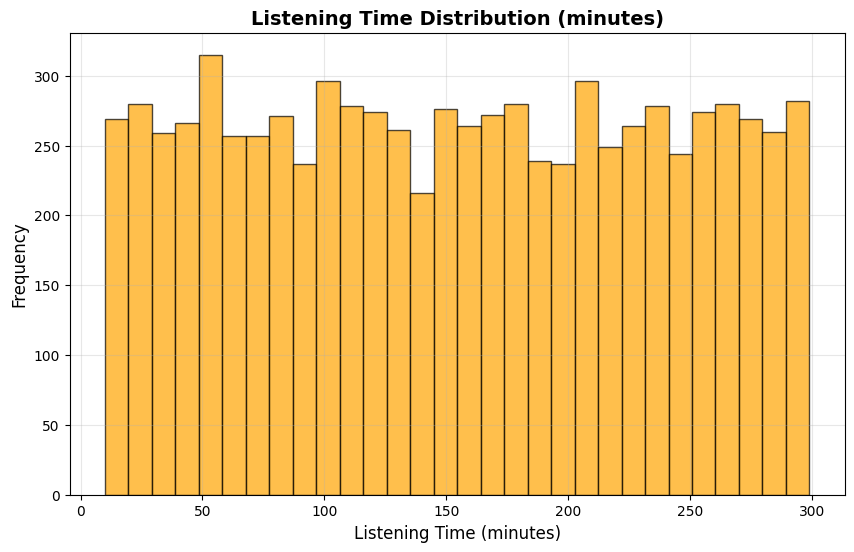

Listening time statistics:
Min: 10, Max: 299, Mean: 154.1


In [15]:
plt.figure(figsize=(10, 6))
plt.hist(df['listening_time'], bins=30, color='orange', alpha=0.7, edgecolor='black')
plt.title('Listening Time Distribution (minutes)', fontsize=14, fontweight='bold')
plt.xlabel('Listening Time (minutes)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(alpha=0.3)
plt.show()
print(f"Listening time statistics:\nMin: {df['listening_time'].min()}, Max: {df['listening_time'].max()}, Mean: {df['listening_time'].mean():.1f}")

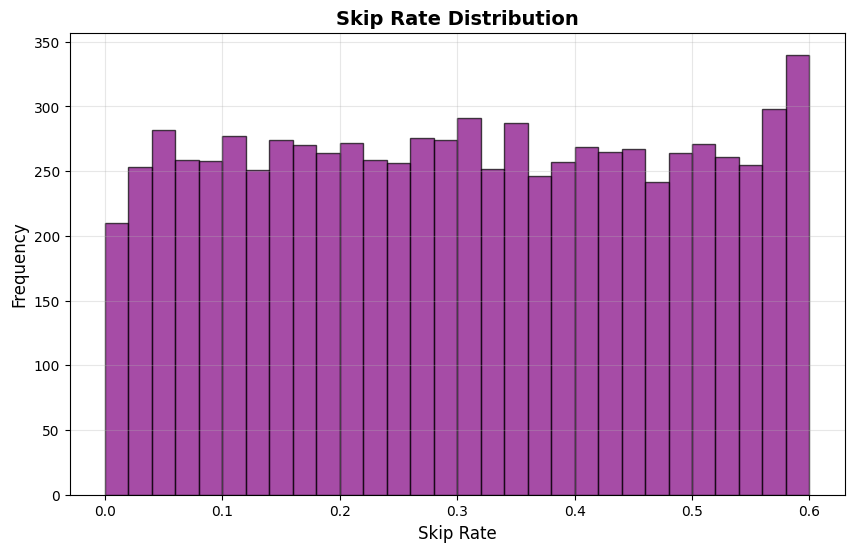

Skip rate statistics:
Min: 0.00, Max: 0.60, Mean: 0.30


In [16]:
plt.figure(figsize=(10, 6))
plt.hist(df['skip_rate'], bins=30, color='purple', alpha=0.7, edgecolor='black')
plt.title('Skip Rate Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Skip Rate', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

print(f"Skip rate statistics:\nMin: {df['skip_rate'].min():.2f}, Max: {df['skip_rate'].max():.2f}, Mean: {df['skip_rate'].mean():.2f}")

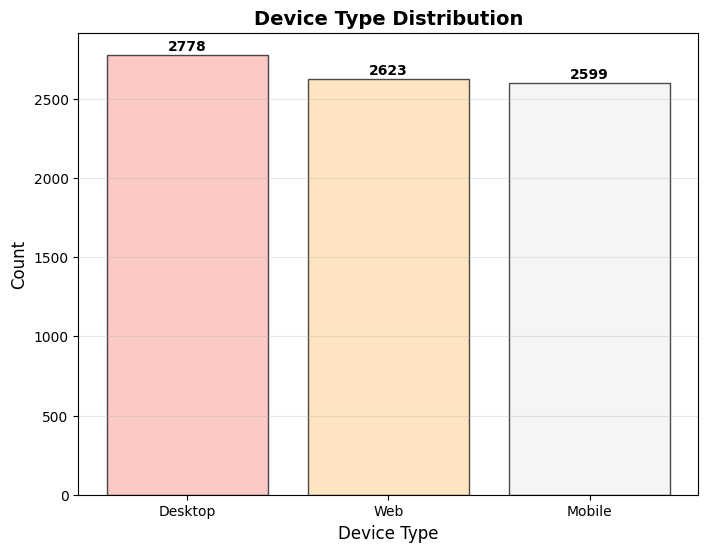

In [17]:
plt.figure(figsize=(8, 6))
device_counts = df['device_type'].value_counts()
colors = plt.cm.Pastel1(np.linspace(0, 1, len(device_counts)))
plt.bar(device_counts.index, device_counts.values, color=colors, alpha=0.7, edgecolor='black')
plt.title('Device Type Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Device Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
for i, v in enumerate(device_counts.values):
    plt.text(i, v + 10, str(v), ha='center', va='bottom', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.show()

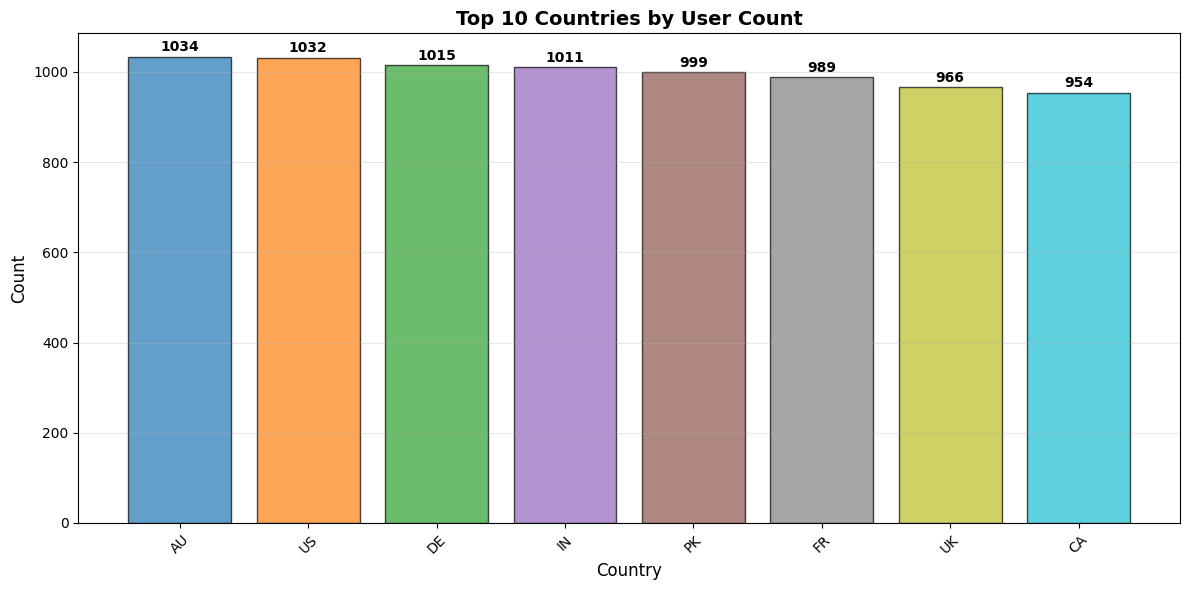

In [18]:
plt.figure(figsize=(12, 6))
country_counts = df['country'].value_counts().head(10)
colors = plt.cm.tab10(np.linspace(0, 1, len(country_counts)))
plt.bar(country_counts.index, country_counts.values, color=colors, alpha=0.7, edgecolor='black')
plt.title('Top 10 Countries by User Count', fontsize=14, fontweight='bold')
plt.xlabel('Country', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
for i, v in enumerate(country_counts.values):
    plt.text(i, v + 5, str(v), ha='center', va='bottom', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

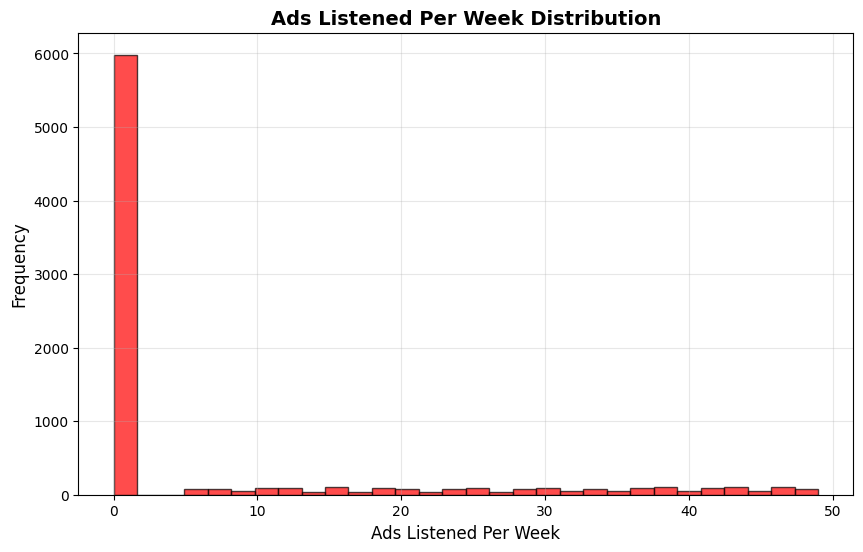

Ads listened statistics:
Min: 0, Max: 49, Mean: 6.9


In [19]:
plt.figure(figsize=(10, 6))
plt.hist(df['ads_listened_per_week'], bins=30, color='red', alpha=0.7, edgecolor='black')
plt.title('Ads Listened Per Week Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Ads Listened Per Week', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

print(f"Ads listened statistics:\nMin: {df['ads_listened_per_week'].min()}, Max: {df['ads_listened_per_week'].max()}, Mean: {df['ads_listened_per_week'].mean():.1f}")

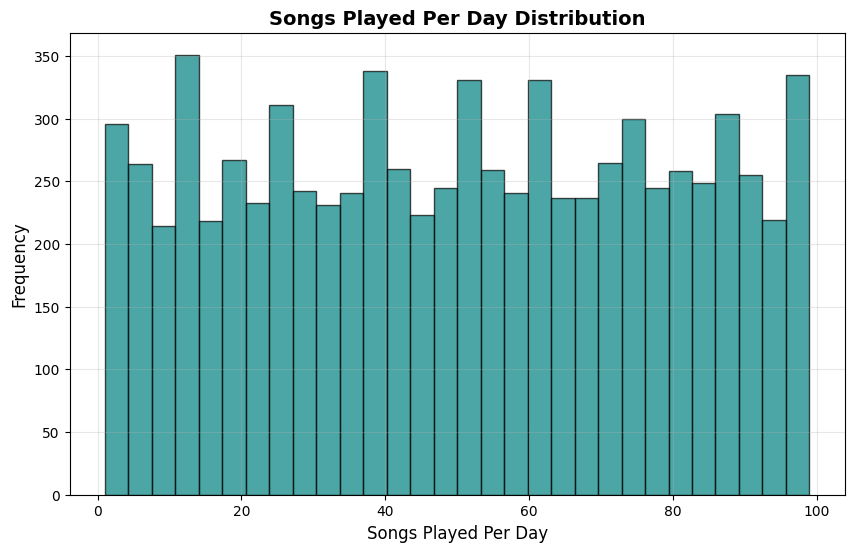

Songs played per day statistics:
Min: 1, Max: 99, Mean: 50.1


In [20]:
plt.figure(figsize=(10, 6))
plt.hist(df['songs_played_per_day'], bins=30, color='teal', alpha=0.7, edgecolor='black')
plt.title('Songs Played Per Day Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Songs Played Per Day', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

print(f"Songs played per day statistics:\nMin: {df['songs_played_per_day'].min()}, Max: {df['songs_played_per_day'].max()}, Mean: {df['songs_played_per_day'].mean():.1f}")

### ii. Churn (Target Variable) distribution by different variables

<Figure size 1000x600 with 0 Axes>

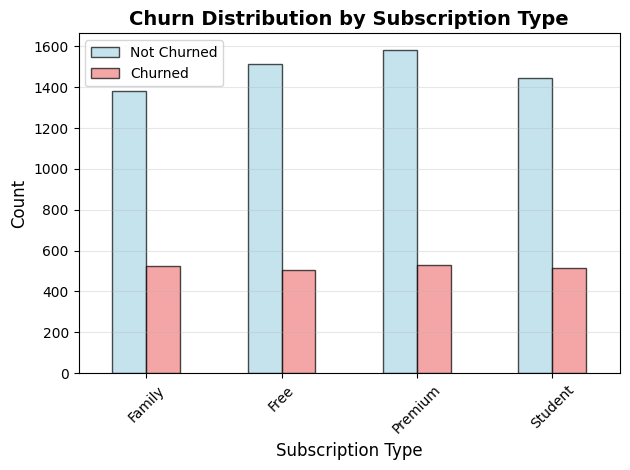

In [21]:
plt.figure(figsize=(10, 6))
churn_by_subscription = pd.crosstab(df['subscription_type'], df['is_churned'])
churn_by_subscription.plot(kind='bar', color=['lightblue', 'lightcoral'], alpha=0.7, edgecolor='black')
plt.title('Churn Distribution by Subscription Type', fontsize=14, fontweight='bold')
plt.xlabel('Subscription Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(['Not Churned', 'Churned'])
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

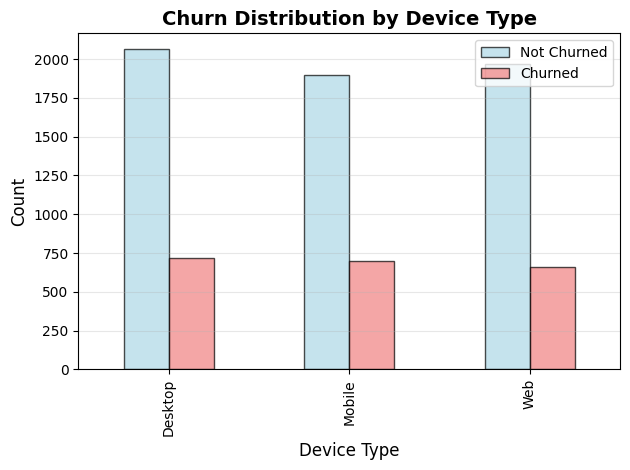

In [22]:
plt.figure(figsize=(8, 6))
churn_by_device = pd.crosstab(df['device_type'], df['is_churned'])
churn_by_device.plot(kind='bar', color=['lightblue', 'lightcoral'], alpha=0.7, edgecolor='black')
plt.title('Churn Distribution by Device Type', fontsize=14, fontweight='bold')
plt.xlabel('Device Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(['Not Churned', 'Churned'])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

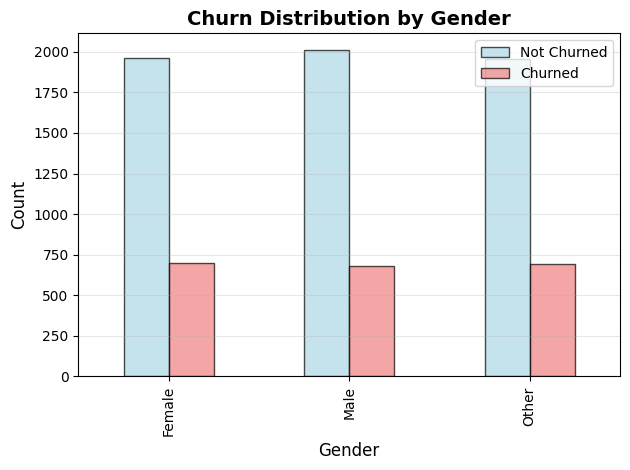

In [23]:
plt.figure(figsize=(8, 6))
churn_by_gender = pd.crosstab(df['gender'], df['is_churned'])
churn_by_gender.plot(kind='bar', color=['lightblue', 'lightcoral'], alpha=0.7, edgecolor='black')
plt.title('Churn Distribution by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(['Not Churned', 'Churned'])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Correlation analysis

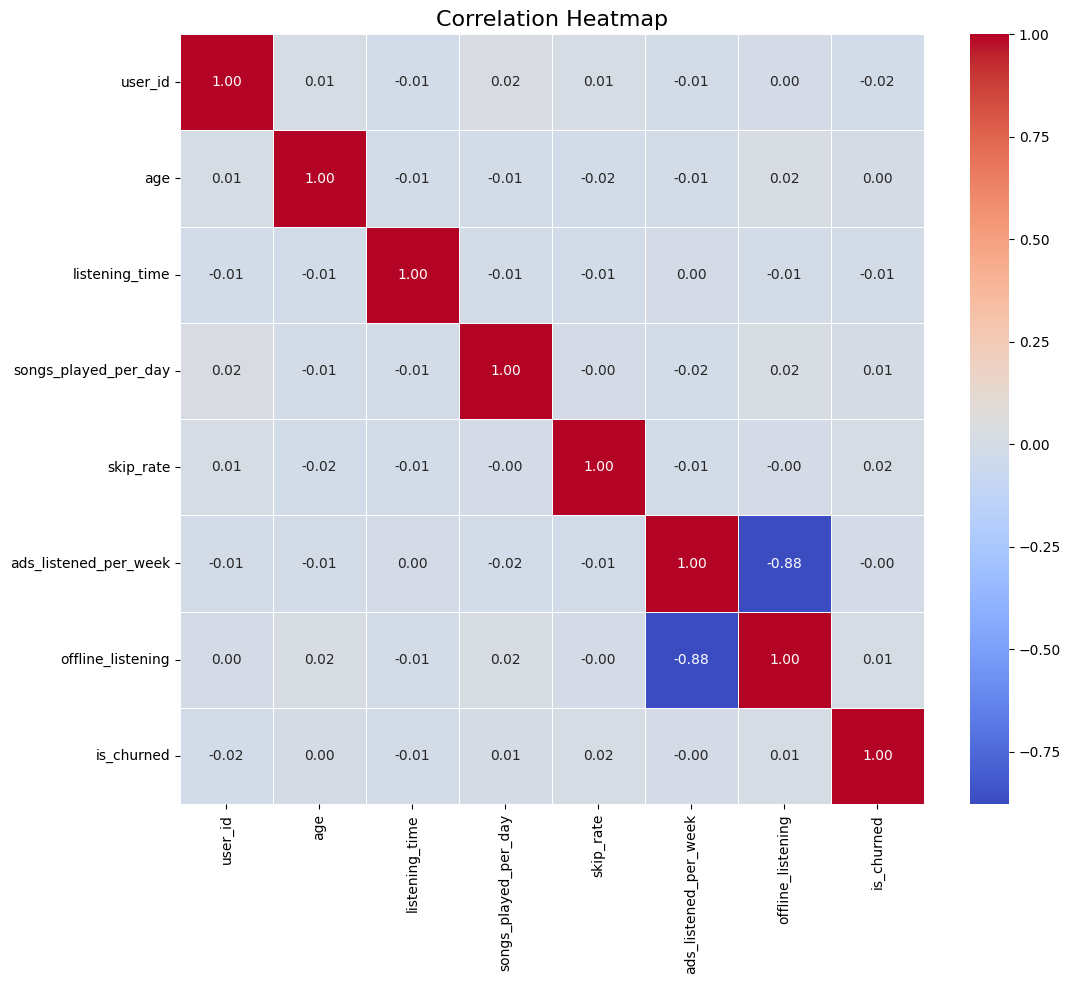

In [24]:
target_col = 'is_churned'

numerical_columns = df.select_dtypes(include=['int64', 'float64'])

correlations = numerical_columns.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    correlations,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=.5,
    cbar=True
)
plt.title('Correlation Heatmap', fontsize=16)
plt.show()

In [25]:
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()
print(correlation_matrix['is_churned'].sort_values(ascending=False))

is_churned               1.000000
skip_rate                0.016121
offline_listening        0.012754
songs_played_per_day     0.009314
age                      0.003982
ads_listened_per_week   -0.002279
listening_time          -0.007624
user_id                 -0.015994
Name: is_churned, dtype: float64


## 7. Data balance

In [26]:
class_counts = df['is_churned'].value_counts()
print("Class distribution:\n", class_counts)

minority = class_counts.min()
majority = class_counts.max()
ratio = majority / minority
print(f"Imbalance ratio ≈ 1:{ratio:.2f}")

Class distribution:
 is_churned
0    5929
1    2071
Name: count, dtype: int64
Imbalance ratio ≈ 1:2.86


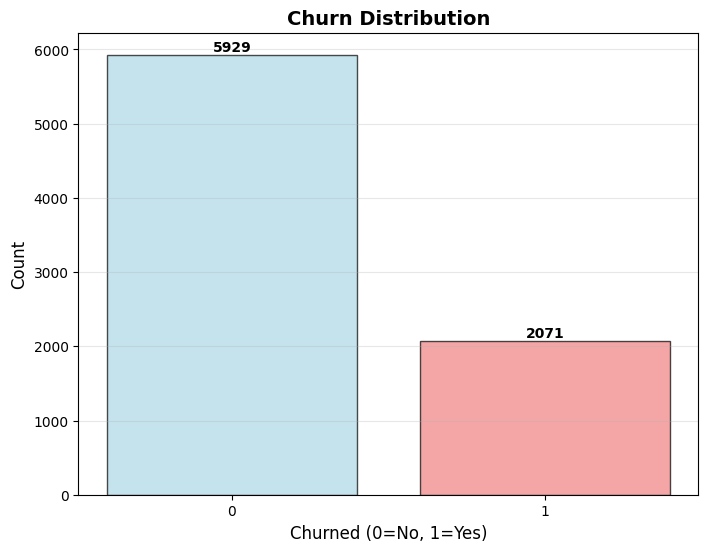

Churn rate: 25.9%


In [27]:
# Target variable distribution
plt.figure(figsize=(8, 6))
churn_counts = df['is_churned'].value_counts()
colors = ['lightblue', 'lightcoral']
plt.bar(churn_counts.index, churn_counts.values, color=colors, alpha=0.7, edgecolor='black')
plt.title('Churn Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Churned (0=No, 1=Yes)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks([0, 1])
for i, v in enumerate(churn_counts.values):
    plt.text(i, v + 10, str(v), ha='center', va='bottom', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"Churn rate: {churn_counts[1] / len(df) * 100:.1f}%")

This imbalance is not extreme (an extreme imbalance is generally around 1:10, as in fraud detection). However, it is significant enough to require specific attention, because:

- Model Bias: A default model could achieve an Accuracy of 74.11% by simply predicting that no one will churn. It might completely ignore the minority class, which is unacceptable for a churn prediction objective.

- Business Objective: The minority class (churn) is the main class of interest (the one the company wants to predict and prevent). Our model must excel at correctly identifying these at-risk users.

# III. Data pre-processing

## 1. Missing values

In [28]:
missing_values = df.isnull().sum()
print(missing_values)

user_id                  0
gender                   0
age                      0
country                  0
subscription_type        0
listening_time           0
songs_played_per_day     0
skip_rate                0
device_type              0
ads_listened_per_week    0
offline_listening        0
is_churned               0
dtype: int64


## 2. Duplicates

In [29]:
if df.duplicated().sum() > 0:
    print(f"Duplicate rows found: {df.duplicated().sum()}")
else:
    print(" No duplicate rows found")

 No duplicate rows found


## 3. Inconsistencies

In [30]:
print("Hello world!")

Hello world!


## 4. Outliers

## 5. Encoding

## 6. Scaling

## 7. Train-test-split

# IV. Models

## 1. Fisrt Models

## 2. Model’s hyperparameter’s tuning

# V. Obstacles

## 1. Overfitting

## 2. Underfitting

## 3. Others

# VI. Relevant Metrics

# VII. Dimension reduction

# VIII. Advanced Models

## 1. Ensemble models

## 2. Others
TODO: use scientific papers as reference

# IX. Comparison

# X. Conclusion